# DDE-SER — RAVDESS (7-Class) Experiment
Calm merged into Neutral. Surprised retained. Run cells top-to-bottom.

Cells 3-4 write module files. Cell 7 loads data. Cell 8 reduces to 7 classes. Cell 9 trains. Cells 10-12 report results.

In [1]:
# Cell 1 — Install dependencies
import subprocess, sys
subprocess.run([sys.executable,'-m','pip','install',
    'numba','librosa','vmdpy','scikit-learn','seaborn','scipy','--quiet'])
print('Ready.')


Ready.


In [3]:
# Cell 2 — Directory setup
import os
for d in ['data/raw_audio/ravdess','data/precomputed_features','modules']:
    os.makedirs(d, exist_ok=True)
print('Directories created.')


Directories created.


In [5]:
%%writefile modules/dde_architecture.py

import tensorflow as tf
from tensorflow.keras.layers import Input, Dense, Layer, Add, Multiply, Flatten, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.applications import VGG16

class GatedAttentionFusion(Layer):
    def __init__(self, **kwargs):
        super(GatedAttentionFusion, self).__init__(**kwargs)

    def build(self, input_shape):
        feature_dim = input_shape[0][-1]
        self.dense_A = Dense(feature_dim, activation='sigmoid', use_bias=True, name='W_att_A')
        self.dense_B = Dense(feature_dim, activation='sigmoid', use_bias=True, name='W_att_B')
        super(GatedAttentionFusion, self).build(input_shape)

    def call(self, inputs):
        v_A, v_B = inputs
        e_A = self.dense_A(v_A)
        e_B = self.dense_B(v_B)
        v_fused = Add()([Multiply()([e_A, v_A]), Multiply()([e_B, v_B])])
        return v_fused, e_A, e_B

def build_dde_ser_model(input_shape_A=(128,128,3), input_shape_B=(128,128,3), num_classes=7):
    input_A = Input(shape=input_shape_A, name='VMD_Input')
    vgg_A   = VGG16(include_top=False, weights='imagenet')
    vgg_A._name = 'VGG16_Branch_A'
    vgg_A.trainable = True
    flat_A  = Flatten(name='v_A')(vgg_A(input_A))

    input_B = Input(shape=input_shape_B, name='HP_Mel_Input')
    vgg_B   = VGG16(include_top=False, weights='imagenet')
    vgg_B._name = 'VGG16_Branch_B'
    vgg_B.trainable = True
    flat_B  = Flatten(name='v_B')(vgg_B(input_B))

    dense_A = Dense(2048, activation='selu')(flat_A)
    dense_B = Dense(2048, activation='selu')(flat_B)

    v_fused, gate_A, gate_B = GatedAttentionFusion(name='Fusion_Layer')([dense_A, dense_B])

    x = Dense(512, activation='selu', kernel_initializer='lecun_normal')(v_fused)
    x = Dropout(0.5)(x)
    x = Dense(256, activation='selu', kernel_initializer='lecun_normal')(x)
    x = Dropout(0.5)(x)
    out = Dense(num_classes, activation='softmax', name='Emotion_Prediction')(x)

    model = Model(inputs=[input_A, input_B], outputs=out)
    try:
        loss_fn = tf.keras.losses.CategoricalFocalCrossentropy(gamma=2.0, alpha=0.25)
    except AttributeError:
        loss_fn = 'categorical_crossentropy'
        print('CategoricalFocalCrossentropy not available — using categorical_crossentropy.')
    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
                  loss=loss_fn, metrics=['accuracy'])
    return model


Overwriting modules/dde_architecture.py


In [7]:
%%writefile modules/feature_extraction.py

import os, glob
import librosa
import numpy as np
from vmdpy import VMD
from tqdm import tqdm

def pad_or_truncate(feat, max_len=128):
    if feat.shape[1] < max_len:
        return np.pad(feat, ((0,0),(0, max_len - feat.shape[1])), mode='constant')
    return feat[:, :max_len]

def extract_branch_A_vmd(y, sr, K=4, alpha=2000, tau=0., DC=0, init=1, tol=1e-7):
    imfs, _, _ = VMD(y, alpha, tau, K, DC, init, tol)
    channels = []
    for i in range(min(3, len(imfs))):
        mel = librosa.feature.melspectrogram(y=imfs[i], sr=sr, n_mels=128, hop_length=512)
        channels.append(pad_or_truncate(librosa.power_to_db(mel, ref=np.max)))
    return np.stack(channels, axis=-1)

def extract_branch_B_hp(y, sr):
    D = librosa.stft(y, n_fft=2048, hop_length=512)
    D_h, D_p = librosa.decompose.hpss(D)
    mel_H = librosa.feature.melspectrogram(S=np.abs(D_h)**2, sr=sr, n_mels=128)
    mel_P = librosa.feature.melspectrogram(S=np.abs(D_p)**2, sr=sr, n_mels=128)
    mel_M = (mel_H + mel_P) / 2.0
    return np.stack([
        pad_or_truncate(librosa.power_to_db(mel_H, ref=np.max)),
        pad_or_truncate(librosa.power_to_db(mel_P, ref=np.max)),
        pad_or_truncate(librosa.power_to_db(mel_M, ref=np.max))
    ], axis=-1)

def process_dataset(raw_audio_dir, save_dir, dataset_name='ravdess'):
    emodb_map   = {'W':0,'L':1,'E':2,'A':3,'F':4,'N':5,'T':6}
    ravdess_map = {'01':5,'02':5,'03':4,'04':6,'05':0,'06':3,'07':2}
    wav_files = glob.glob(os.path.join(raw_audio_dir,'**','*.wav'), recursive=True)
    if not wav_files:
        print(f'No .wav files found in {raw_audio_dir}'); return
    X_A, X_B, Y, speakers = [], [], [], []
    print(f'Found {len(wav_files)} files. Extracting {dataset_name}...')
    for file in tqdm(wav_files):
        fn = os.path.basename(file)
        try:
            if dataset_name.lower() == 'ravdess':
                parts = fn.split('.')[0].replace('_extd','').split('-')
                if len(parts) != 7: raise ValueError(f'Bad RAVDESS name: {fn}')
                ec = parts[2]
                if ec not in ravdess_map: continue
                emotion, speaker_id = ravdess_map[ec], int(parts[6])
            elif dataset_name.lower() == 'emodb':
                base = fn.split('.')[0].replace('_doubled','').replace('_tripled','')
                if len(base) != 7: raise ValueError(f'Bad EMO-DB name: {base}')
                ec = base[5]
                if ec not in emodb_map: continue
                emotion, speaker_id = emodb_map[ec], int(base[:2])
        except Exception as e:
            print(f'Skipping {fn}: {e}'); continue
        y, sr = librosa.load(file, sr=44100, duration=3.0)
        X_A.append(extract_branch_A_vmd(y, sr))
        X_B.append(extract_branch_B_hp(y, sr))
        Y.append(emotion)
        speakers.append(speaker_id)
    os.makedirs(save_dir, exist_ok=True)
    np.save(os.path.join(save_dir, f'{dataset_name}_vmd_128.npy'), np.array(X_A))
    np.save(os.path.join(save_dir, f'{dataset_name}_hp_128.npy'),  np.array(X_B))
    ul, Ym = np.unique(Y, return_inverse=True)
    np.save(os.path.join(save_dir, f'{dataset_name}_labels.npy'),   np.eye(len(ul))[Ym])
    np.save(os.path.join(save_dir, f'{dataset_name}_speakers.npy'), np.array(speakers))
    print(f'{dataset_name.upper()} done — {len(Y)} samples, {len(ul)} classes.')


Overwriting modules/feature_extraction.py


## Feature Extraction (run once)
Skip Cell 6 if `.npy` files already exist. Otherwise place RAVDESS `.wav` files in `data/raw_audio/ravdess/` and run.

In [9]:
# Cell 6 — Feature extraction (comment out if .npy files already exist)
# from modules.feature_extraction import process_dataset
# process_dataset('data/raw_audio/ravdess/','data/precomputed_features/',dataset_name='ravdess')
print('Using pre-computed .npy files.')


Using pre-computed .npy files.


In [11]:
# Cell 7 — Load RAVDESS data & normalise
%reload_ext autoreload
%autoreload 2

import os, gc
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats as scipy_stats
from sklearn.model_selection import LeaveOneGroupOut
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from modules.dde_architecture import build_dde_ser_model

gpus = tf.config.list_physical_devices('GPU')
if gpus:
    [tf.config.experimental.set_memory_growth(g, True) for g in gpus]
    print('GPU memory growth enabled.')

FEAT        = 'data/precomputed_features/'
X_A         = np.load(FEAT + 'ravdess_vmd_128.npy')
X_B         = np.load(FEAT + 'ravdess_hp_128.npy')
Y_raw       = np.load(FEAT + 'ravdess_labels.npy')
speaker_ids = np.load(FEAT + 'ravdess_speakers.npy')

X_A = (X_A - X_A.min()) / (X_A.max() - X_A.min() + 1e-8)
X_B = (X_B - X_B.min()) / (X_B.max() - X_B.min() + 1e-8)

print(f'Branch A : {X_A.shape}  |  Branch B : {X_B.shape}')
print(f'Labels   : {Y_raw.shape}  |  Speakers : {speaker_ids.shape}')


C:\Users\User\anaconda3\lib\site-packages\google\api_core\_python_version_support.py:246: FutureWarning: You are using a non-supported Python version (3.8.20). Google will not post any further updates to google.api_core supporting this Python version. Please upgrade to the latest Python version, or at least Python 3.10, and then update google.api_core.
  warnings.warn(message, FutureWarning)


GPU memory growth enabled.
Branch A : (2760, 128, 128, 3)  |  Branch B : (2760, 128, 128, 3)
Labels   : (2760, 8)  |  Speakers : (2760,)


In [13]:
# Cell 8 — 7-Class label reduction  (Calm merged into Neutral, Surprised kept)
#
#  Final 7-class index:
#    0=Neutral(inc.Calm)  1=Happiness  2=Sadness  3=Anger  4=Fear  5=Disgust  6=Surprised

RAVDESS_LABELS      = ['Neutral (inc. Calm)','Happiness','Sadness',
                        'Anger','Fear','Disgust','Surprised']
RAVDESS_LABELS_PLOT = ['Neutral\n(inc. Calm)','Happiness','Sadness',
                        'Anger','Fear','Disgust','Surprised']
ABBREV = ['Neu','Hap','Sad','Ang','Fea','Dis','Sur']

n_cols = Y_raw.shape[1]
y_int  = np.argmax(Y_raw, axis=1)

if n_cols == 8:
    y_int[y_int == 1] = 0                              # Calm -> Neutral
    remap = {0:0, 2:1, 3:2, 4:3, 5:4, 6:5, 7:6}
    y_7c  = np.array([remap[v] for v in y_int])
    print('8-column labels: Calm merged into Neutral, re-indexed to 7 classes.')
elif n_cols == 7:
    # Labels from current feature_extraction.py (6-class after np.unique — re-map)
    remap = {0:3, 2:5, 3:4, 4:1, 5:0, 6:2}           # ext order -> canonical
    y_7c  = np.array([remap.get(v, v) for v in y_int])
    print('7-column labels: re-mapped to canonical 7-class order.')
else:
    raise ValueError(f'Unexpected label columns: {n_cols}. Expected 7 or 8.')

Y_7c       = tf.keras.utils.to_categorical(y_7c, num_classes=7)
n_speakers = len(np.unique(speaker_ids))

print(f'\n7-Class distribution ({n_speakers} speakers, {n_speakers} LOSO folds):')
for i, nm in enumerate(RAVDESS_LABELS):
    print(f'  [{i}] {nm:<25}: {int(np.sum(y_7c==i)):>5} samples')


8-column labels: Calm merged into Neutral, re-indexed to 7 classes.

7-Class distribution (23 speakers, 23 LOSO folds):
  [0] Neutral (inc. Calm)      :   552 samples
  [1] Happiness                :   368 samples
  [2] Sadness                  :   368 samples
  [3] Anger                    :   368 samples
  [4] Fear                     :   368 samples
  [5] Disgust                  :   368 samples
  [6] Surprised                :   368 samples


In [15]:
# Cell 9 — LOSO Training Loop
logo              = LeaveOneGroupOut()
fold_accuracies   = []
all_true_labels   = []
all_predictions   = []
all_probabilities = []

for fold, (train_idx, test_idx) in enumerate(
        logo.split(X_A, Y_7c, groups=speaker_ids)):

    print(f'--- Starting LOSO Fold {fold+1} / {n_speakers} ---')

    X_A_tr, X_A_te = X_A[train_idx], X_A[test_idx]
    X_B_tr, X_B_te = X_B[train_idx], X_B[test_idx]
    Y_tr,   Y_te   = Y_7c[train_idx], Y_7c[test_idx]

    y_int_tr = np.argmax(Y_tr, axis=1)
    cw = compute_class_weight('balanced', classes=np.unique(y_int_tr), y=y_int_tr)
    cw_dict = dict(enumerate(cw))

    model = build_dde_ser_model(num_classes=7)

    cbs = [
        tf.keras.callbacks.EarlyStopping(
            monitor='val_loss', patience=15, restore_best_weights=True),
        tf.keras.callbacks.ModelCheckpoint(
            filepath=f'best_model_ravdess_fold_{fold+1}.h5',
            monitor='val_accuracy', save_best_only=True,
            save_weights_only=True, verbose=0)
    ]

    model.fit([X_A_tr, X_B_tr], Y_tr,
              validation_data=([X_A_te, X_B_te], Y_te),
              epochs=100, batch_size=32, class_weight=cw_dict,
              callbacks=cbs, verbose=0)

    loss, acc = model.evaluate([X_A_te, X_B_te], Y_te, verbose=0)
    fold_accuracies.append(acc)
    print(f'    Fold {fold+1} Accuracy: {acc:.4f}')

    probs = model.predict([X_A_te, X_B_te], verbose=0)
    all_probabilities.extend(probs)
    all_predictions.extend(np.argmax(probs, axis=1))
    all_true_labels.extend(np.argmax(Y_te, axis=1))

    del model, X_A_tr, X_A_te, X_B_tr, X_B_te, Y_tr, Y_te
    tf.keras.backend.clear_session()
    gc.collect()

fold_accuracies = np.array(fold_accuracies)
print(f'\nOverall LOSO Accuracy: {np.mean(fold_accuracies):.4f} +/- {np.std(fold_accuracies):.4f}')


--- Starting LOSO Fold 1 / 23 ---
CategoricalFocalCrossentropy not available — using categorical_crossentropy.
    Fold 1 Accuracy: 0.6000
--- Starting LOSO Fold 2 / 23 ---
CategoricalFocalCrossentropy not available — using categorical_crossentropy.
    Fold 2 Accuracy: 0.9250
--- Starting LOSO Fold 3 / 23 ---
CategoricalFocalCrossentropy not available — using categorical_crossentropy.
    Fold 3 Accuracy: 0.7250
--- Starting LOSO Fold 4 / 23 ---
CategoricalFocalCrossentropy not available — using categorical_crossentropy.
    Fold 4 Accuracy: 0.6000
--- Starting LOSO Fold 5 / 23 ---
CategoricalFocalCrossentropy not available — using categorical_crossentropy.
    Fold 5 Accuracy: 0.7000
--- Starting LOSO Fold 6 / 23 ---
CategoricalFocalCrossentropy not available — using categorical_crossentropy.
    Fold 6 Accuracy: 0.6500
--- Starting LOSO Fold 7 / 23 ---
CategoricalFocalCrossentropy not available — using categorical_crossentropy.
    Fold 7 Accuracy: 0.8417
--- Starting LOSO Fold 8 / 

In [17]:
# Cell 10 — Statistics, Classification Report & AUC
n_folds  = len(fold_accuracies)
mean_acc = np.mean(fold_accuracies)
sd_d1    = np.std(fold_accuracies, ddof=1)   # sample SD (report in paper)
sd_d0    = np.std(fold_accuracies, ddof=0)   # matches log format
ci_95    = scipy_stats.t.interval(0.95, df=n_folds-1,
               loc=mean_acc, scale=scipy_stats.sem(fold_accuracies))

print('='*60)
print(f'RAVDESS 7-CLASS LOSO RESULTS  ({n_folds} folds)')
print('='*60)
print(f'  Mean accuracy  : {mean_acc:.4f}  ({mean_acc*100:.2f}%)')
print(f'  SD  (ddof=1)   : {sd_d1:.4f}  ({sd_d1*100:.2f}%)  <- report in paper')
print(f'  SD  (ddof=0)   : {sd_d0:.4f}  ({sd_d0*100:.2f}%)  <- matches log')
print(f'  Min fold       : {fold_accuracies.min():.4f}  ({fold_accuracies.min()*100:.2f}%)')
print(f'  Max fold       : {fold_accuracies.max():.4f}  ({fold_accuracies.max()*100:.2f}%)')
print(f'  95% CI (t)     : [{ci_95[0]*100:.2f}%, {ci_95[1]*100:.2f}%]')
print(f'  Fold values    : {list(np.round(fold_accuracies*100,2))}')
print(f'\nOverall LOSO Accuracy: {mean_acc:.4f} +/- {sd_d0:.4f}')

print('\n'+'='*60+'\nCLASSIFICATION REPORT\n'+'='*60)
print(classification_report(all_true_labels, all_predictions,
      target_names=RAVDESS_LABELS, digits=4))

print('--- AUC Scores (One-vs-Rest) ---')
probs_arr  = np.array(all_probabilities)
auc_scores = []
for i, lbl in enumerate(RAVDESS_LABELS):
    y_bin = (np.array(all_true_labels) == i).astype(int)
    auc   = roc_auc_score(y_bin, probs_arr[:, i])
    auc_scores.append(auc)
    print(f'  {lbl:<25}: {auc:.4f}')
print(f'  Macro AUC               : {np.mean(auc_scores):.4f}')


RAVDESS 7-CLASS LOSO RESULTS  (23 folds)
  Mean accuracy  : 0.6217  (62.17%)
  SD  (ddof=1)   : 0.1393  (13.93%)  <- report in paper
  SD  (ddof=0)   : 0.1362  (13.62%)  <- matches log
  Min fold       : 0.3583  (35.83%)
  Max fold       : 0.9250  (92.50%)
  95% CI (t)     : [56.15%, 68.20%]
  Fold values    : [60.0, 92.5, 72.5, 60.0, 70.0, 65.0, 84.17, 79.17, 54.17, 64.17, 48.33, 61.67, 35.83, 47.5, 47.5, 81.67, 60.83, 60.0, 59.17, 53.33, 70.83, 40.83, 60.83]

Overall LOSO Accuracy: 0.6217 +/- 0.1362

CLASSIFICATION REPORT
                     precision    recall  f1-score   support

Neutral (inc. Calm)     0.6754    0.6975    0.6863       552
          Happiness     0.5096    0.4321    0.4676       368
            Sadness     0.4220    0.4484    0.4348       368
              Anger     0.6832    0.7092    0.6960       368
               Fear     0.6099    0.5353    0.5702       368
            Disgust     0.7056    0.6902    0.6978       368
          Surprised     0.6991    0.8016  

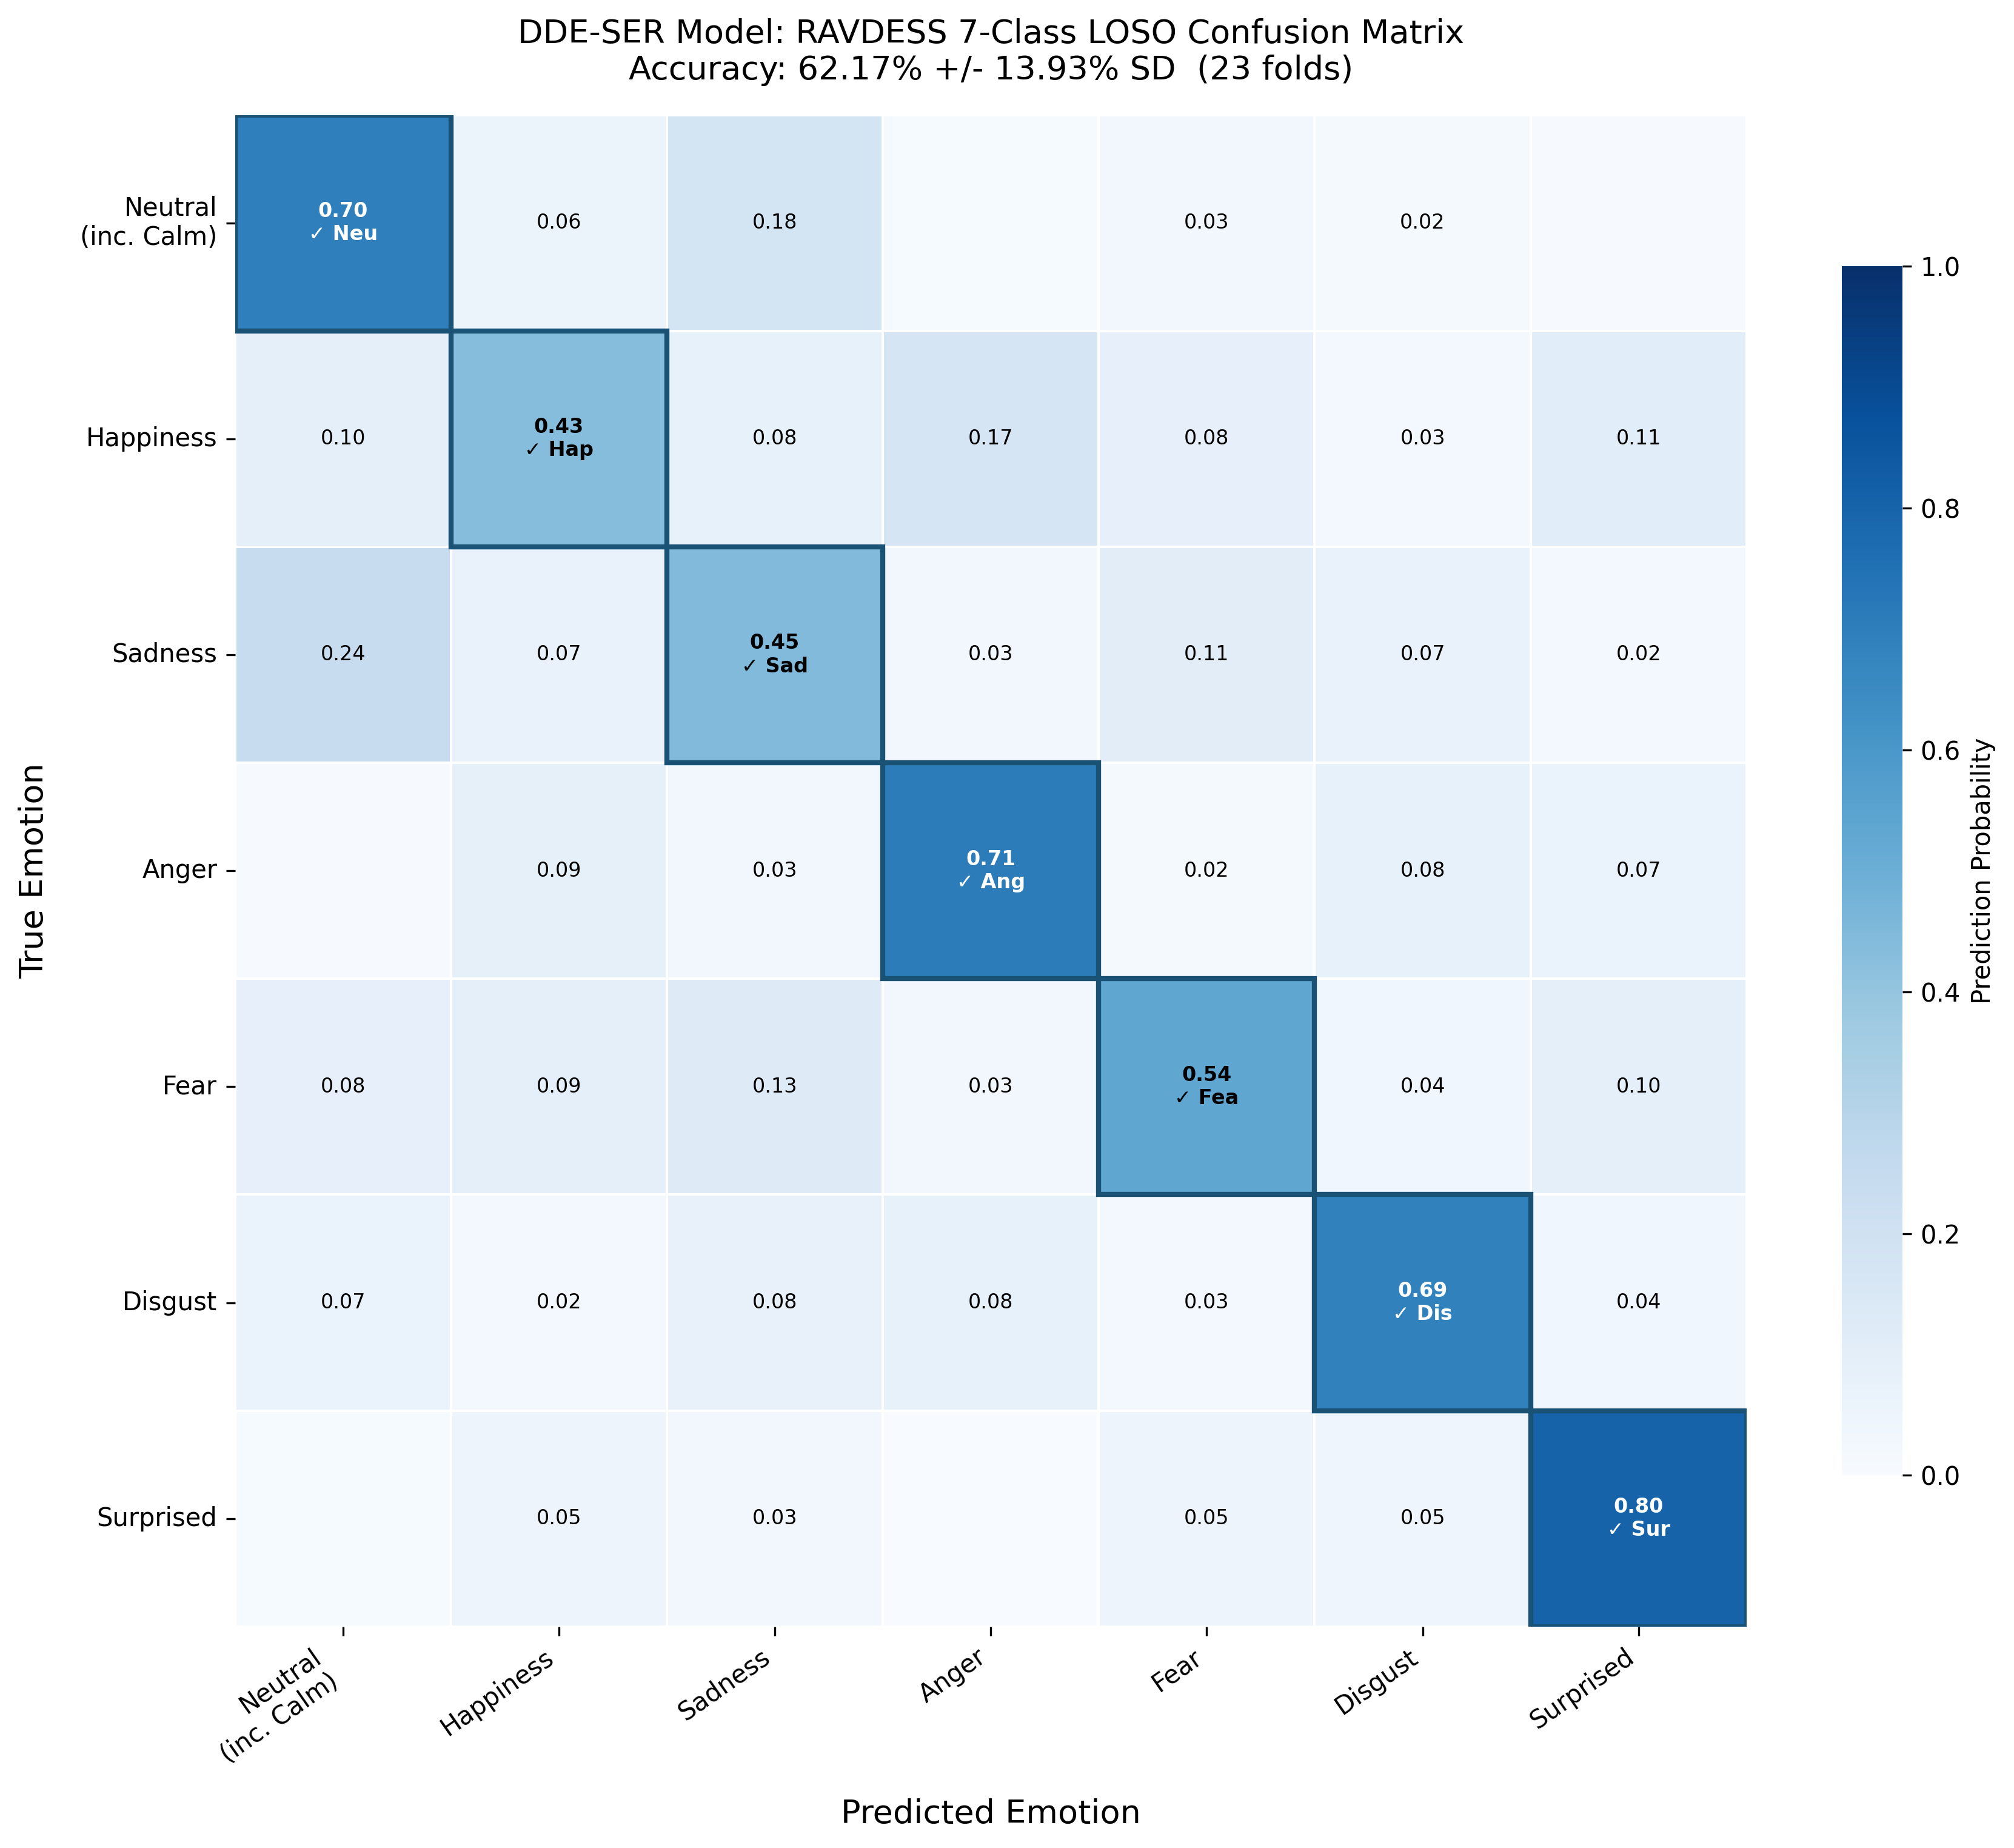

Saved: ravdess_confusion_matrix.pdf / .png


In [19]:
# Cell 11 — Confusion Matrix with Emotion Labels
cm_raw  = confusion_matrix(all_true_labels, all_predictions)
cm_norm = confusion_matrix(all_true_labels, all_predictions, normalize='true')
n_cls   = len(RAVDESS_LABELS)

fig, ax = plt.subplots(figsize=(12, 10), dpi=300)
sns.heatmap(cm_norm, ax=ax, cmap='Blues', vmin=0.0, vmax=1.0,
            linewidths=0.5, linecolor='white', square=True,
            cbar_kws={'label':'Prediction Probability','shrink':0.80},
            annot=False,
            xticklabels=RAVDESS_LABELS_PLOT, yticklabels=RAVDESS_LABELS_PLOT)

for i in range(n_cls):
    for j in range(n_cls):
        prob  = cm_norm[i, j]
        color = 'white' if prob > 0.55 else 'black'
        if i == j:
            txt, wt = f'{prob:.2f}\n\u2713 {ABBREV[j]}', 'bold'
        else:
            txt, wt = (f'{prob:.2f}' if prob >= 0.01 else ''), 'normal'
        ax.text(j+0.5, i+0.5, txt, ha='center', va='center',
                fontsize=8, fontweight=wt, color=color)

for i in range(n_cls):
    ax.add_patch(plt.Rectangle((i,i),1,1,fill=False,
                 edgecolor='#1a5276',linewidth=2.0,zorder=3))

ax.set_xlabel('Predicted Emotion', fontsize=13, labelpad=12)
ax.set_ylabel('True Emotion',      fontsize=13, labelpad=12)
ax.set_title(f'DDE-SER Model: RAVDESS 7-Class LOSO Confusion Matrix\n'
             f'Accuracy: {mean_acc*100:.2f}% +/- {sd_d1*100:.2f}% SD  ({n_folds} folds)',
             fontsize=13, pad=14)
ax.set_xticklabels(RAVDESS_LABELS_PLOT, rotation=35, ha='right', fontsize=10)
ax.set_yticklabels(RAVDESS_LABELS_PLOT, rotation=0,  ha='right', fontsize=10)
plt.tight_layout()
plt.savefig('ravdess_confusion_matrix.pdf', dpi=300, bbox_inches='tight')
plt.savefig('ravdess_confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.show()
print('Saved: ravdess_confusion_matrix.pdf / .png')


In [21]:
# Cell 12 — LaTeX snippets (auto-filled once training is complete)
print('='*60+'\nPASTE INTO MANUSCRIPT\n'+'='*60)
print('\n% -- Table 2: Overall Accuracy row --')
print(f'\\multicolumn{{4}}{{c}}{{Overall Accuracy: {mean_acc*100:.2f}\\%'
      f' $\\pm$ {sd_d1*100:.2f}\\% (SD)}} \\\\\\')
print('\\bottomrule')

print('\n% -- Table 2 caption --')
print(f'\\caption{{Classification Metrics for the Augmented RAVDESS Dataset using SICV.'
      f' Calm is merged with Neutral (``Neutral (inc. Calm)\'\'). '
      f'Overall accuracy is the mean across all {n_folds} SICV folds; '
      f'$\\pm$ denotes the sample SD (95\\% CI: [{ci_95[0]*100:.2f}\\%, {ci_95[1]*100:.2f}\\%]).}}')

print('\n% -- Section 5.2 prose sentence --')
print(f'Fold-wise overall accuracy ranged from {fold_accuracies.min()*100:.2f}\\%'
      f' to {fold_accuracies.max()*100:.2f}\\% across all {n_folds} held-out speakers'
      f' (SD = {sd_d1*100:.2f}\\%, 95\\% CI: [{ci_95[0]*100:.2f}\\%, {ci_95[1]*100:.2f}\\%]).')


PASTE INTO MANUSCRIPT

% -- Table 2: Overall Accuracy row --
\multicolumn{4}{c}{Overall Accuracy: 62.17\% $\pm$ 13.93\% (SD)} \\\
\bottomrule

% -- Table 2 caption --
\caption{Classification Metrics for the Augmented RAVDESS Dataset using SICV. Calm is merged with Neutral (``Neutral (inc. Calm)''). Overall accuracy is the mean across all 23 SICV folds; $\pm$ denotes the sample SD (95\% CI: [56.15\%, 68.20\%]).}

% -- Section 5.2 prose sentence --
Fold-wise overall accuracy ranged from 35.83\% to 92.50\% across all 23 held-out speakers (SD = 13.93\%, 95\% CI: [56.15\%, 68.20\%]).
